# 05.02 — Model Experiments
**Goal:** Try different hyperparameter settings and feature subsets.
Find the best combination. Compare against baseline.

Experiments:
1. Tune scale_pos_weight
2. Tune tree depth
3. Tune learning rate + n_estimators
4. Feature selection: drop low-importance features
5. Best params combined


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

import json
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid
from src.models.train import cross_validate, DEFAULT_PARAMS
from src.models.evaluate import evaluate_model

train_df = pd.read_parquet(FEATURES / 'train_2024.parquet')
test_df  = pd.read_parquet(FEATURES / 'test_2025.parquet')
with open(FEATURES / 'feature_cols.json') as f:
    feature_cols = json.load(f)

test_decided = test_df[test_df['churn_label'].notna()].copy()
test_decided['churn_label'] = test_decided['churn_label'].astype(int)

X_train = train_df[feature_cols]
y_train = train_df['churn_label'].astype(int)
X_test  = test_decided[feature_cols]
y_test  = test_decided['churn_label']

experiment_results = []


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Experiment 1 — scale_pos_weight

Testing scale_pos_weight values...
  spw=5    PR-AUC=0.9512  Recall=0.9299
  spw=7    PR-AUC=0.9520  Recall=0.9297
  spw=9.5  PR-AUC=0.9518  Recall=0.9297
  spw=12   PR-AUC=0.9510  Recall=0.9294
  spw=15   PR-AUC=0.9521  Recall=0.9298

Best scale_pos_weight: 15


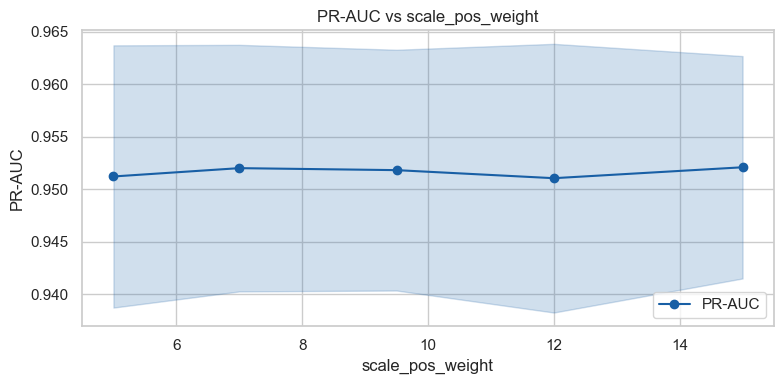

In [2]:

spw_values = [5, 7, 9.5, 12, 15]
print("Testing scale_pos_weight values...")
spw_results = []
for spw in spw_values:
    params = DEFAULT_PARAMS.copy()
    params['scale_pos_weight'] = spw
    r = cross_validate(X_train, y_train, params=params, n_splits=3, verbose=False)
    spw_results.append({'scale_pos_weight': spw, **r})
    print(f"  spw={spw:<4} PR-AUC={r['pr_auc_mean']:.4f}  Recall={r['f1_mean']:.4f}")

best_spw = max(spw_results, key=lambda x: x['pr_auc_mean'])['scale_pos_weight']
print(f"\nBest scale_pos_weight: {best_spw}")

fig, ax = plt.subplots(figsize=(8, 4))
spw_df = pd.DataFrame(spw_results)
ax.plot(spw_df['scale_pos_weight'], spw_df['pr_auc_mean'], 'o-', color='#185FA5', label='PR-AUC')
ax.fill_between(spw_df['scale_pos_weight'],
                spw_df['pr_auc_mean']-spw_df['pr_auc_std'],
                spw_df['pr_auc_mean']+spw_df['pr_auc_std'], alpha=0.2, color='#185FA5')
ax.set_title('PR-AUC vs scale_pos_weight')
ax.set_xlabel('scale_pos_weight')
ax.set_ylabel('PR-AUC')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'exp1_scale_pos_weight.png', dpi=150, bbox_inches='tight')
plt.show()


## Experiment 2 — Tree Depth

In [3]:

depth_values = [3, 4, 5, 6, 7]
print("Testing max_depth values...")
depth_results = []
for d in depth_values:
    params = DEFAULT_PARAMS.copy()
    params['max_depth'] = d
    params['scale_pos_weight'] = best_spw
    r = cross_validate(X_train, y_train, params=params, n_splits=3, verbose=False)
    depth_results.append({'max_depth': d, **r})
    print(f"  depth={d}  PR-AUC={r['pr_auc_mean']:.4f}")

best_depth = max(depth_results, key=lambda x: x['pr_auc_mean'])['max_depth']
print(f"\nBest max_depth: {best_depth}")


Testing max_depth values...
  depth=3  PR-AUC=0.9468
  depth=4  PR-AUC=0.9494
  depth=5  PR-AUC=0.9521
  depth=6  PR-AUC=0.9520
  depth=7  PR-AUC=0.9513

Best max_depth: 5


## Experiment 3 — Learning Rate & Estimators

In [4]:

lr_configs = [
    {'learning_rate': 0.10, 'n_estimators': 200},
    {'learning_rate': 0.05, 'n_estimators': 400},
    {'learning_rate': 0.03, 'n_estimators': 600},
    {'learning_rate': 0.01, 'n_estimators': 1000},
]
print("Testing learning rate / n_estimators combinations...")
lr_results = []
for cfg in lr_configs:
    params = DEFAULT_PARAMS.copy()
    params.update(cfg)
    params['scale_pos_weight'] = best_spw
    params['max_depth'] = best_depth
    r = cross_validate(X_train, y_train, params=params, n_splits=3, verbose=False)
    lr_results.append({**cfg, **r})
    print(f"  lr={cfg['learning_rate']}  n={cfg['n_estimators']}  PR-AUC={r['pr_auc_mean']:.4f}")

best_lr_cfg = max(lr_results, key=lambda x: x['pr_auc_mean'])
print(f"\nBest: lr={best_lr_cfg['learning_rate']}, n_estimators={best_lr_cfg['n_estimators']}")


Testing learning rate / n_estimators combinations...
  lr=0.1  n=200  PR-AUC=0.9484
  lr=0.05  n=400  PR-AUC=0.9510
  lr=0.03  n=600  PR-AUC=0.9514
  lr=0.01  n=1000  PR-AUC=0.9504

Best: lr=0.03, n_estimators=600


## Experiment 4 — Feature Selection (drop weak features)

In [5]:

from xgboost import XGBClassifier
import json

# Train with best params to get importances
best_params_so_far = DEFAULT_PARAMS.copy()
best_params_so_far['scale_pos_weight'] = best_spw
best_params_so_far['max_depth'] = best_depth
best_params_so_far['learning_rate'] = best_lr_cfg['learning_rate']
best_params_so_far['n_estimators'] = best_lr_cfg['n_estimators']

temp_model = XGBClassifier(**best_params_so_far)
temp_model.fit(X_train, y_train, verbose=False)

fi = pd.Series(temp_model.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

# Try dropping bottom 20% features
threshold_pct = 0.01  # drop features with importance < 1% of max
important_features = fi_sorted[fi_sorted >= fi_sorted.max() * threshold_pct].index.tolist()
print(f"Features retained: {len(important_features)} / {len(feature_cols)}")
print(f"Features dropped: {len(feature_cols) - len(important_features)}")

r_full    = cross_validate(X_train, y_train, params=best_params_so_far, n_splits=3, verbose=False)
r_reduced = cross_validate(X_train[important_features], y_train, params=best_params_so_far, n_splits=3, verbose=False)
print(f"\nFull features    PR-AUC: {r_full['pr_auc_mean']:.4f}")
print(f"Reduced features PR-AUC: {r_reduced['pr_auc_mean']:.4f}")

use_reduced = r_reduced['pr_auc_mean'] >= r_full['pr_auc_mean'] - 0.002
print(f"\nUse reduced feature set: {use_reduced}")
final_feature_cols = important_features if use_reduced else feature_cols


Features retained: 51 / 91
Features dropped: 40

Full features    PR-AUC: 0.9514
Reduced features PR-AUC: 0.9518

Use reduced feature set: True


## Best Model from Experiments

Best hyperparameters:
  n_estimators: 600
  max_depth: 5
  learning_rate: 0.03
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  gamma: 0.1
  reg_alpha: 0.1
  reg_lambda: 1.0
  scale_pos_weight: 15
  eval_metric: aucpr
  use_label_encoder: False
  random_state: 42
  n_jobs: -1
[0]	validation_0-aucpr:0.79811
[50]	validation_0-aucpr:0.79410
[100]	validation_0-aucpr:0.79307
[150]	validation_0-aucpr:0.79445
[200]	validation_0-aucpr:0.79996
[250]	validation_0-aucpr:0.80124
[300]	validation_0-aucpr:0.80409
[350]	validation_0-aucpr:0.80145
[400]	validation_0-aucpr:0.80025
[450]	validation_0-aucpr:0.79891
[500]	validation_0-aucpr:0.79719
[550]	validation_0-aucpr:0.79649
[599]	validation_0-aucpr:0.79559
Model saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\models_saved\churn_model_v2_tuned.json
Model Evaluation — v2_tuned
  Threshold used:    0.000
  PR-AUC:            0.7956
  ROC-AUC:           0.5108
  Precision:         0.7888
  Recall:            1.0000

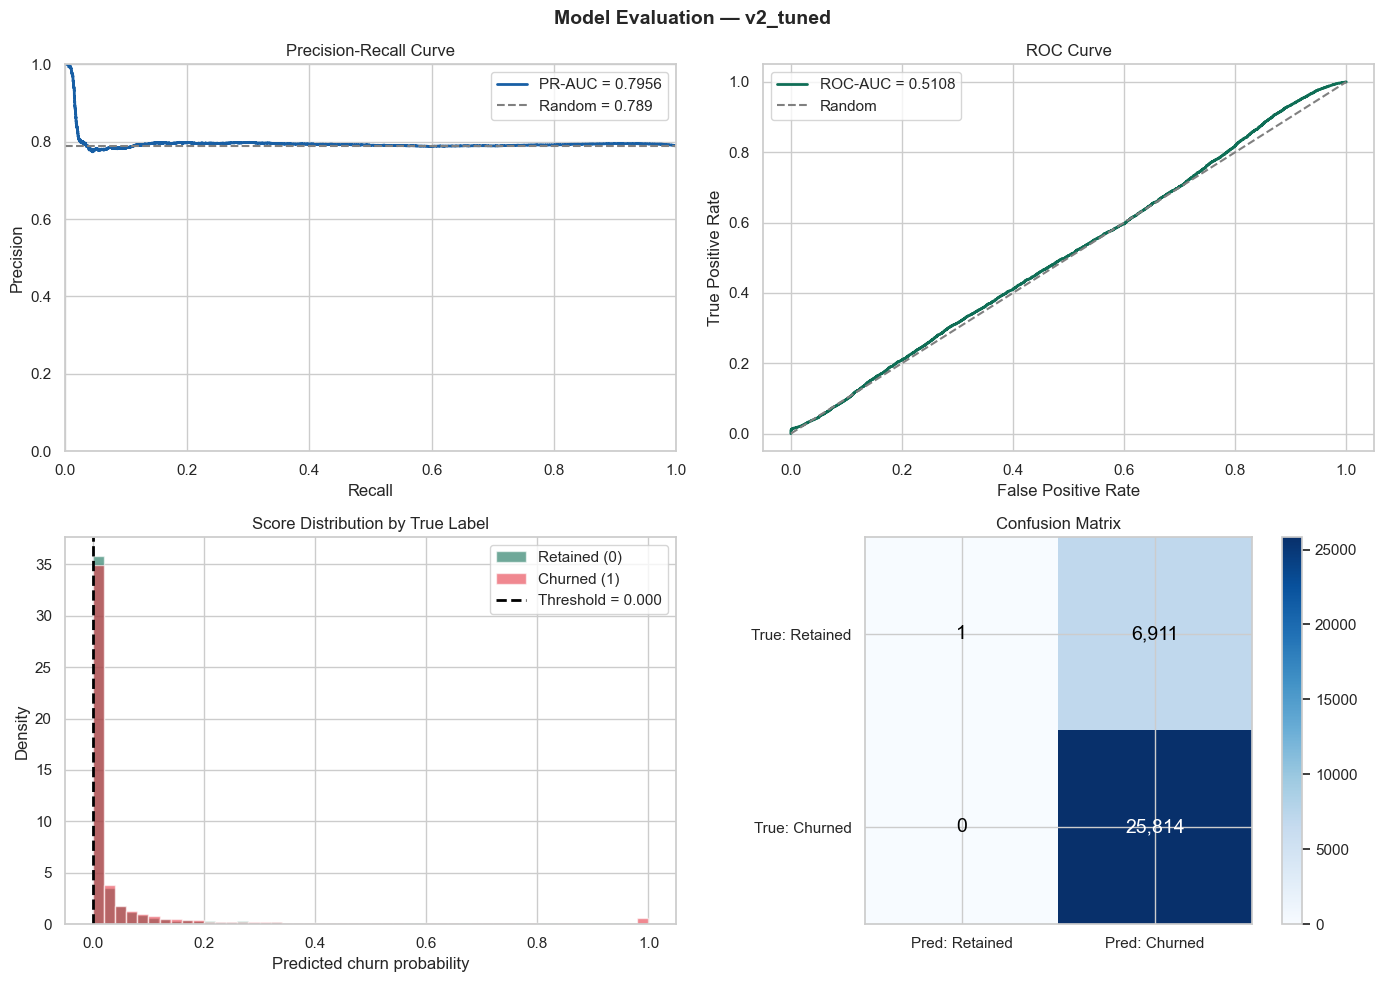

Plot saved → C:\Users\vaddi\OneDrive\Desktop\post_renewal_churn_prediction\reports\figures\v2_tuned_evaluation.png

Saved final features and params.


In [7]:

from src.models.train import train_final_model
from src.models.evaluate import evaluate_model

best_params = best_params_so_far.copy()
print("Best hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

model_v2 = train_final_model(
    X_train[final_feature_cols], y_train,
    X_val=X_test[final_feature_cols], y_val=y_test,
    params=best_params,
    model_name='churn_model_v2_tuned'
)
v2_metrics = evaluate_model(model_v2, X_test[final_feature_cols], y_test,
                             model_name='v2_tuned', save_plots=True)

# Save final feature list
with open(FEATURES / 'final_feature_cols.json', 'w') as f:
    json.dump(final_feature_cols, f, indent=2)
with open(MODELS / 'best_params.json', 'w') as f:
    save_p = {k:v for k,v in best_params.items() if isinstance(v,(int,float,str,bool))}
    json.dump(save_p, f, indent=2)
print("\nSaved final features and params.")
